In [3]:
# ── Notebook 8: RAG (Retrieval-Augmented Generation) ────────────────────
# Goal  : let the chatbot answer questions about a PDF document by indexing
#         it in a vector store and exposing retrieval as a tool.
# New   :
#   PyPDFLoader                    – extract text from a PDF file
#   RecursiveCharacterTextSplitter – split long text into overlapping chunks
#   GoogleGenerativeAIEmbeddings   – embed chunks into dense vectors
#   Chroma                         – in-process vector database
#   rag_tool                       – @tool running a retriever query
# New packages: chromadb, pypdf, langchain-google-genai
# ─────────────────────────────────────────────────────────────────────────

!uv pip install langgraph langchain langchain-core langchain-community chromadb pypdf langchain-google-genai ddgs langchain-mistralai dotenv langgraph-checkpoint-sqlite --quiet

In [4]:
# ── Imports ──────────────────────────────────────────────────────────────
# TypedDict / Annotated / Literal  – typed state schema helpers
# BaseMessage / HumanMessage / AIMessage / ToolMessage – LangChain message types
# ChatMistralAI                    – Mistral AI chat model wrapper
# add_messages                     – reducer: appends msgs instead of overwriting
# StateGraph / START / END         – graph builder and sentinel nodes
# ToolNode / tools_condition       – prebuilt tool executor node and router
# MemorySaver / SqliteSaver        – in-RAM / SQLite-backed checkpointers
# interrupt / Command              – HITL primitives (pause & resume graph)
# trim_messages                    – slice message history to fit token budget

from typing import TypedDict, Literal, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_mistralai import ChatMistralAI
from dotenv import load_dotenv

from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.tools import tool

from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

from langgraph.checkpoint.sqlite import SqliteSaver
import sqlite3

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_community.vectorstores import Chroma

import requests

In [5]:
# Load environment variables from .env (MISTRAL_API_KEY, LANGCHAIN_API_KEY, etc.).

load_dotenv()

True

In [6]:
llm = ChatMistralAI()

In [7]:
# ── Document Loading ────────────────────────────────────────────────────
# PyPDFLoader reads the PDF page-by-page, returning one Document per page
# with text content and metadata (page number, source path).

# ── Document Loading ─────────────────────────────────────────────────────
# PyPDFLoader reads a PDF page-by-page and returns a list of Documents,
# each carrying the page text and metadata (page number, source path).

loader = PyPDFLoader("./../../resources/research-papers/yolo_melanoma_final.pdf")
docs = loader.load()

In [8]:
# Sanity check: print the number of pages loaded from the PDF.

len(docs)

4

In [9]:
# ── Text Splitting ──────────────────────────────────────────────────────
# RecursiveCharacterTextSplitter divides pages into overlapping chunks
# so each chunk fits within the embedding model's token limit.
# chunk_size=1000, chunk_overlap=200 preserves cross-boundary context.

# ── Text Splitting ───────────────────────────────────────────────────────
# Splits long documents into smaller chunks before embedding because:
#   1. Embedding models have token limits.
#   2. Smaller chunks give more precise retrieval hits.
# chunk_size=1000, chunk_overlap=200 (overlap preserves cross-chunk context).

splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [10]:
# ── Embeddings & Vector Store ───────────────────────────────────────────
# Each chunk is converted to a dense vector via Google's embedding model.
# Chroma stores them in a local collection for fast similarity search.

# ── Embeddings & Vector Store ────────────────────────────────────────────
# GoogleGenerativeAIEmbeddings converts each chunk into a dense vector.
# Chroma.from_documents() embeds all chunks and stores them for fast search.

embeddings = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001",)
vector_store = Chroma.from_documents(chunks, embeddings)

In [11]:
vector_store

In [12]:
# ── Retriever ───────────────────────────────────────────────────────────
# Wraps the Chroma collection with a similarity-search interface.
# k=4 returns the 4 most semantically relevant chunks per query.

# ── Retriever ────────────────────────────────────────────────────────────
# Wraps the vector store with a search interface.
# search_type='similarity', k=4 returns the 4 most relevant chunks.

retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [13]:
# ── RAG Tool ────────────────────────────────────────────────────────────
# @tool exposes retrieve-from-vector-store as a callable LangChain tool.
# The LLM will invoke this when the user asks document-specific questions.

@tool
def rag_tool(query):

    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents.
    """
    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

In [14]:
# tools
search_tool = DuckDuckGoSearchRun(region="us-en")

In [15]:
# ── Stock Price Tool ────────────────────────────────────────────────────
# @tool that calls the Alpha Vantage API to fetch the latest stock quote.
# The LLM passes the ticker symbol; the function returns raw JSON.

@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=C9PE94QUEW9VWGFM"
    r = requests.get(url)
    return r.json()

In [16]:
# ── Calculator Tool ─────────────────────────────────────────────────────
# @tool for basic arithmetic (add/sub/mul/div) on two floats.
# Avoids the LLM making arithmetic errors by delegating to Python.

@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}
        
        return {"first_num": first_num, "second_num": second_num, "operation": operation, "result": result}
    except Exception as e:
        return {"error": str(e)}

In [17]:
# ── Graph State ─────────────────────────────────────────────────────────
# ChatState is the single shared data structure flowing through the graph.
# add_messages reducer ensures new messages are *appended*, not replaced.

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [18]:
# ── Tool List (expanded with RAG) ────────────────────────────────────────
# rag_tool is added alongside existing tools. The LLM chooses it when the
# user's question is best answered by searching the indexed PDF.

# Make tool list
tools = [get_stock_price, search_tool, calculator, rag_tool]

# Make the LLM tool-aware
llm_with_tools = llm.bind_tools(tools)

In [19]:
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    
    # take user query from state
    messages = state['messages']
    
    # send to llm
    response = llm.invoke(messages)
    # response store state
    return {'messages': [response]}
tool_node = ToolNode(tools)  # Executes tool calls

In [20]:
# ── SQLite Connection ────────────────────────────────────────────────────
# Open (or create) chatbot.db. check_same_thread=False allows the
# connection to be used from the graph's internal threads safely.

conn = sqlite3.connect(database="chatbot.db", check_same_thread=False)
# checkpointer
checkpointer = SqliteSaver(conn=conn)

In [21]:
# checkpointer = MemorySaver()
# graph structure
graph = StateGraph(ChatState)
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

In [22]:
graph.add_edge(START, "chat_node")
# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge("tools", "chat_node")  

In [23]:
# ── Compile the Graph ───────────────────────────────────────────────────
# compile() locks the graph structure and wires in the checkpointer.
# After this call the graph is immutable and ready to run.

chatbot = graph.compile(
    checkpointer=checkpointer
)

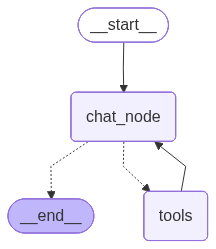

In [24]:
chatbot

In [25]:
# initial_state = {
#     'messages': [HumanMessage(content="What is the capital of India?")]
# }
# chatbot.invoke(initial_state)['messages'][-1].content

In [26]:
# ── Thread Selection ────────────────────────────────────────────────────
# List existing threads from the SQLite checkpoint so users can resume
# a previous conversation. Each thread_id is a UUID string.

import uuid

# --- Thread selection ---
# The 'checkpoints' table is created by SqliteSaver on the first save.
# On a fresh database it won't exist yet, so we catch that error and
# treat it the same as having no previous threads.
try:
    existing = conn.execute(
        "SELECT DISTINCT thread_id FROM checkpoints ORDER BY thread_id"
    ).fetchall()
except Exception:
    existing = []

if existing:
    print('Existing threads:')
    for i, (tid,) in enumerate(existing, 1):
        print(f'  [{i}] {tid}')
    print(f'  [n] Start a new thread')
    choice = input('Select a thread number or "n" for new: ').strip().lower()
    if choice == 'n' or not choice.isdigit():
        thread_id = str(uuid.uuid4())
        print(f'New thread created: {thread_id}')
    else:
        idx = int(choice) - 1
        thread_id = existing[idx][0]
        print(f'Resuming thread: {thread_id}')
else:
    thread_id = str(uuid.uuid4())
    print(f'No existing threads found. New thread created: {thread_id}')

Existing threads:
  [1] 07193a44-42d2-44d8-a435-ab2a44d07ffb
  [n] Start a new thread
New thread created: b7800c3c-ad6e-4fad-91e7-436921390d78


In [28]:
# --- Chat loop ---
while True:

    user_query = input('Ask your query: ')

    print('User: ', user_query)

    if not user_query.strip():
        print('Please enter a non-empty query.')
        continue

    if user_query.strip().lower() in ['exit', 'bye', 'fuck you', 'quit']:
        print('AI: Hope you got answers')
        break

    config = {
        'configurable': {
            'thread_id': thread_id,
            # [NEW] metadata is attached to every LangSmith trace for this run,
            # making it easy to filter traces by thread in the observability dashboard.
            'metadata': {
                'thread_id': thread_id
            },
            # [NEW] run_name labels each invocation in LangSmith so you can
            # tell individual chat turns apart at a glance.
            'run_name': 'chat_turn'
        }
    }

    for message_chunk, metadata in chatbot.stream(
        { 'messages' : [HumanMessage(content=user_query)] },
        config=config,
        stream_mode='messages'
    ): 
        if message_chunk.content:
            print(message_chunk.content, end="", flush=True)
    print()

User:  what is decison tree?
A **Decision Tree** is a **supervised machine learning algorithm** used for both **classification** and **regression** tasks. It works by recursively splitting the dataset into subsets based on the most significant features, ultimately forming a tree-like structure where each internal node represents a decision (based on a feature), branches represent possible outcomes, and leaf nodes represent the final prediction.

### **Key Components of a Decision Tree:**
1. **Root Node** – The topmost decision node (first split).
2. **Internal Nodes (Decision Nodes)** – Represent features used for splitting.
3. **Branches (Edges)** – Represent possible outcomes of a decision.
4. **Leaf Nodes (Terminal Nodes)** – Represent the final predicted class or value.

### **How a Decision Tree Works:**
1. **Select the Best Feature** – The algorithm chooses the feature that best splits the data (maximizes information gain or reduces impurity).
2. **Split the Data** – The dataset 